In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version PyTorch is using: {torch.version.cuda}")
print(f"Is the GPU recognized? {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu130
CUDA version PyTorch is using: 13.0
Is the GPU recognized? True


In [2]:
import os
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import cohen_kappa_score

## Configuration

In [3]:
ZIP_PATH = Path("train_processed_final.zip")     
LABELS_CSV = Path("trainLabels.csv")             
EXTRACT_DIR = Path("train_processed_data")       
MODEL_SAVE_PATH = Path("best_convnext_tiny.pth")

NUM_CLASSES = 5
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
VAL_SIZE = 0.2
NUM_WORKERS = 0
IMG_SIZE = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [4]:
if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [5]:
labels_df = pd.read_csv(LABELS_CSV)
print(labels_df.head())
print(labels_df.columns.tolist())

      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1
['image', 'level']


## Image path mapping

In [6]:
image_files = list(EXTRACT_DIR.rglob("*.jpg")) + list(EXTRACT_DIR.rglob("*.jpeg")) + list(EXTRACT_DIR.rglob("*.png"))
print("Total extracted image files:", len(image_files))
image_map = {img.stem: img for img in image_files}
print("Mapped image stems:", len(image_map))

Total extracted image files: 35126
Mapped image stems: 35126


## Match labels with available images

In [7]:
labels_df["image_path"] = labels_df["image"].map(image_map)
labels_df = labels_df.dropna(subset=["image_path"]).copy()

labels_df["image_path"] = labels_df["image_path"].astype(str)
labels_df["level"] = labels_df["level"].astype(int)

print("Matched samples:", len(labels_df))
print(labels_df["level"].value_counts().sort_index())
labels_df.head()

Matched samples: 35126
level
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64


,image,level,image_path
0,10_left,0,train_processed_data/10_left.jpg
1,10_right,0,train_processed_data/10_right.jpg
2,13_left,0,train_processed_data/13_left.jpg
3,13_right,0,train_processed_data/13_right.jpg
4,15_left,1,train_processed_data/15_left.jpg


In [8]:
train_df, val_df = train_test_split(
    labels_df,
    test_size = VAL_SIZE,
    stratify = labels_df["level"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

Train size: 28100
Val size: 7026


In [9]:
train_df.to_csv("train_dataset.csv", index=False)
val_df.to_csv("val_dataset.csv", index=False)

In [10]:
train_df = pd.read_csv("train_dataset.csv")   
val_df = pd.read_csv("val_dataset.csv")   

## Data Augmentation

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation(degrees = 10),
    transforms.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.05, hue = 0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

## Creating Dataset

In [12]:
class DRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        label = int(self.df.iloc[idx]["level"])
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Failed to load image: {img_path}") from e
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = DRDataset(train_df, transform=train_transform)
val_dataset = DRDataset(val_df, transform=val_transform)

## Handling Class Imbalance
Ref: <href>https://www.geeksforgeeks.org/deep-learning/handling-class-imbalance-in-pytorch/</href>

In [13]:
class_counts = train_df["level"].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = train_df["level"].map(lambda x: class_weights[x]).values

sampler = WeightedRandomSampler(
    weights = torch.DoubleTensor(sample_weights),
    num_samples = len(sample_weights),
    replacement = True
)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [20648  1954  4234   698   566]
Class weights: [4.84308408e-05 5.11770727e-04 2.36183278e-04 1.43266476e-03
 1.76678445e-03]


/tmp/ipykernel_158518/3893889094.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  weights = torch.DoubleTensor(sample_weights),


## Data Loaders
Ref: <href>https://docs.pytorch.org/docs/stable/data.html</href>

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    sampler = sampler,
    num_workers = NUM_WORKERS,
    pin_memory = True,
    persistent_workers = False,
    prefetch_factor = None
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS,
    pin_memory = True,
    persistent_workers = False,
    prefetch_factor = None
)

## Loading ConvNeXt-Tiny
Using pre-trained weights

In [15]:
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights = weights)

in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(DEVICE)
print(model)

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

## Loss, Optimizer, Scheduler, Mixed Precision

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr = LR,
    weight_decay = WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = "max",
    factor = 0.5,
    patience = 2
)
scaler = torch.amp.GradScaler(enabled = (DEVICE.type == "cuda"))

## Model Training

In [23]:
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
from tqdm.auto import tqdm
import torch

def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")


def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Training", leave=True, ascii = True)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="weighted")
    epoch_qwk = quadratic_weighted_kappa(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1, epoch_qwk


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation", leave=True, ascii = True)

        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="weighted")
    epoch_qwk = quadratic_weighted_kappa(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1, epoch_qwk, all_labels, all_preds

In [24]:
history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "train_qwk": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_qwk": []
}

best_val_qwk = -1.0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")

    train_loss, train_acc, train_f1, train_qwk = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE
    )

    val_loss, val_acc, val_f1, val_qwk, val_labels, val_preds = validate_one_epoch(
        model, val_loader, criterion, DEVICE
    )

    scheduler.step(val_qwk)   # since QWK should be maximized

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["train_qwk"].append(train_qwk)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["val_qwk"].append(val_qwk)

    print(
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Train F1: {train_f1:.4f} | Train QWK: {train_qwk:.4f}"
    )
    print(
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f} | Val QWK: {val_qwk:.4f}"
    )

    if val_qwk > best_val_qwk:
        best_val_qwk = val_qwk
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Best model saved based on QWK: {MODEL_SAVE_PATH}")
        history = {
                "train_loss": [],
                "train_acc": [],
                "train_f1": [],
                "train_qwk": [],
                "val_loss": [],
                "val_acc": [],
                "val_f1": [],
                "val_qwk": []
            }

best_val_qwk = -1.0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")

    train_loss, train_acc, train_f1, train_qwk = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE
    )

    val_loss, val_acc, val_f1, val_qwk, val_labels, val_preds = validate_one_epoch(
        model, val_loader, criterion, DEVICE
    )

    scheduler.step(val_qwk)   # since QWK should be maximized

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["train_qwk"].append(train_qwk)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["val_qwk"].append(val_qwk)

    print(
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Train F1: {train_f1:.4f} | Train QWK: {train_qwk:.4f}"
    )
    print(
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f} | Val QWK: {val_qwk:.4f}"
    )

    if val_qwk > best_val_qwk:
        best_val_qwk = val_qwk
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Best model saved based on QWK: {MODEL_SAVE_PATH}")


Epoch [1/10]


Training:   0%|          | 0/879 [00:00<?, ?it/s]

Validation:   0%|          | 0/220 [00:00<?, ?it/s]

Train Loss: 0.3328 | Train Acc: 0.8669 | Train F1: 0.8669 | Train QWK: 0.9238
Val Loss: 0.8678 | Val Acc: 0.7149 | Val F1: 0.7189 | Val QWK: 0.5916
Best model saved based on QWK: best_convnext_tiny.pth

Epoch [2/10]


Training:   0%|          | 0/879 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/220 [00:00<?, ?it/s]

Train Loss: 0.0211 | Train Acc: 0.9929 | Train F1: 0.9929 | Train QWK: 0.9943
Val Loss: 1.5866 | Val Acc: 0.7935 | Val F1: 0.7562 | Val QWK: 0.6144

Epoch [10/10]


Training:   0%|          | 0/879 [00:00<?, ?it/s]

Validation:   0%|          | 0/220 [00:00<?, ?it/s]

Train Loss: 0.0178 | Train Acc: 0.9939 | Train F1: 0.9939 | Train QWK: 0.9958
Val Loss: 1.5868 | Val Acc: 0.7982 | Val F1: 0.7599 | Val QWK: 0.6396


## Plot training history

In [25]:
import pandas as pd
from pathlib import Path

# history_df = pd.read_csv("training_history.csv") 
history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = "epoch"

history_csv_path = Path("training_history.csv")
history_df.to_csv(history_csv_path, index=True)

print("Saved history to:", history_csv_path.resolve())
history_df.head()

Saved history to: /user/HS401/mn01409/Documents/Diabetic-Retinopathy-Grading-Group-34/training_history.csv


,train_loss,train_acc,train_f1,train_qwk,val_loss,val_acc,val_f1,val_qwk
epoch,,,,,,,,
1,0.059204,0.978754,0.978736,0.984191,1.204471,0.785084,0.761957,0.648633
2,0.050215,0.982349,0.982343,0.986472,1.245195,0.772986,0.754489,0.637491
3,0.052174,0.981352,0.981339,0.985432,1.263593,0.785226,0.762692,0.653702
4,0.050667,0.982349,0.982334,0.986661,1.337227,0.774409,0.756239,0.647780
5,0.044944,0.984128,0.984122,0.988148,1.363054,0.732280,0.735106,0.608570


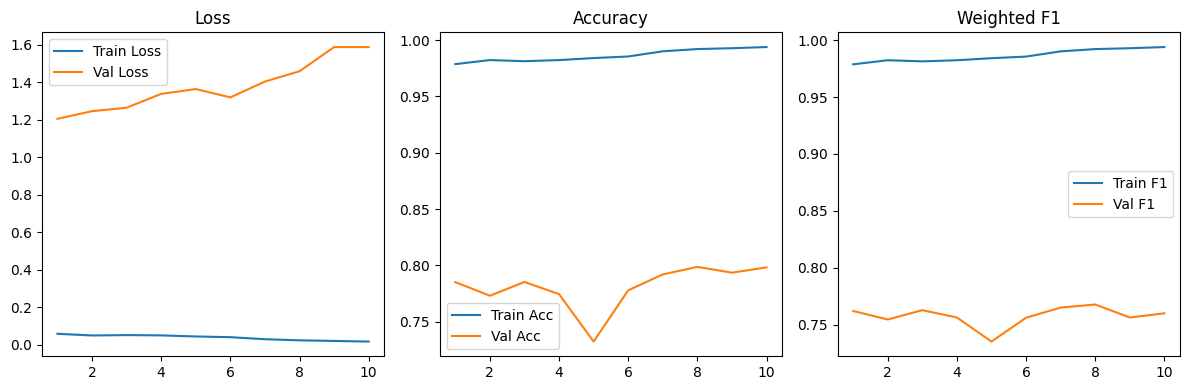

In [26]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, history["train_f1"], label="Train F1")
plt.plot(epochs, history["val_f1"], label="Val F1")
plt.title("Weighted F1")
plt.legend()

plt.tight_layout()
plt.show()

## Load best model and evaluate

In [28]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location = DEVICE))
model.eval()

val_loss, val_acc, val_f1, val_qwk, val_labels, val_preds = validate_one_epoch(
        model, val_loader, criterion, DEVICE
    )

print("Best Validation Accuracy:", val_acc)
print("Best Validation Weighted F1:", val_f1)

Validation:   0%|          | 0/220 [00:00<?, ?it/s]

Best Validation Accuracy: 0.7852263023057217
Best Validation Weighted F1: 0.7626920489853277


## Classification Report

In [29]:
print(classification_report(val_labels, val_preds, digits=4))

              precision    recall  f1-score   support

           0     0.8425    0.9324    0.8851      5162
           1     0.2062    0.0818    0.1171       489
           2     0.5779    0.4981    0.5350      1058
           3     0.5424    0.3657    0.4369       175
           4     0.8202    0.5141    0.6320       142

    accuracy                         0.7852      7026
   macro avg     0.5978    0.4784    0.5212      7026
weighted avg     0.7504    0.7852    0.7627      7026



## Confusion Matrix

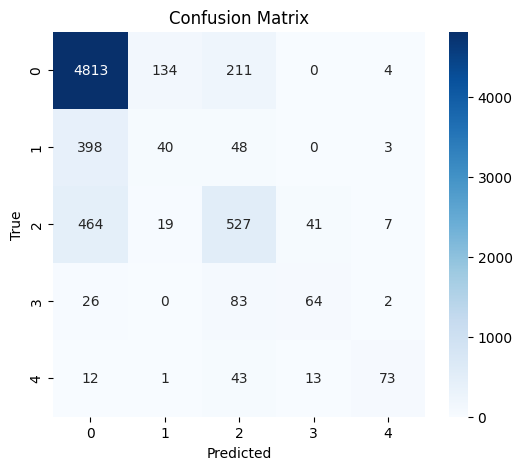

In [30]:
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Normalised Confusion Matrix

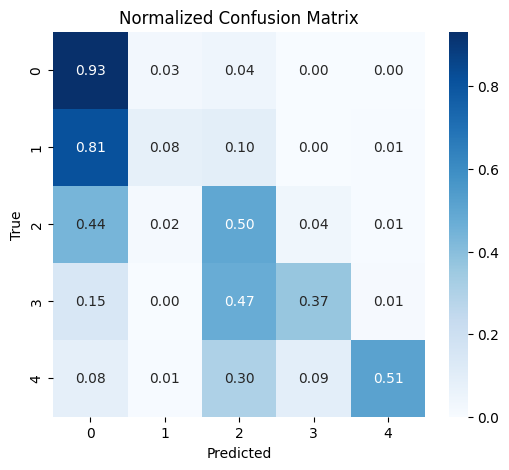

In [31]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_labels, val_preds, labels=[0,1,2,3,4])
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[0,1,2,3,4],
    yticklabels=[0,1,2,3,4]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

## Support per class bar chart

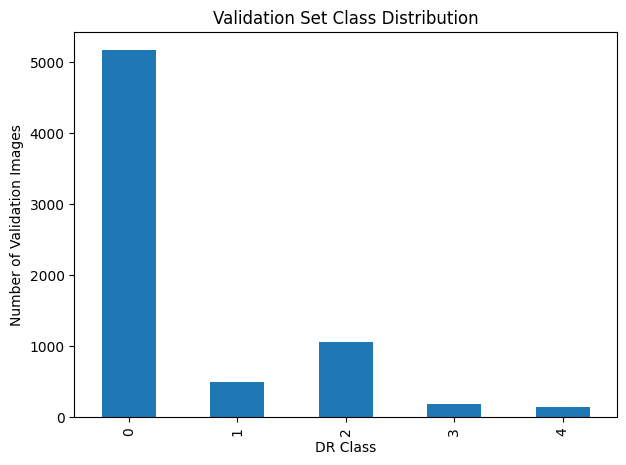

In [32]:
val_df["level"].value_counts().sort_index().plot(kind="bar", figsize=(7,5))
plt.xlabel("DR Class")
plt.ylabel("Number of Validation Images")
plt.title("Validation Set Class Distribution")
plt.show()

## Pre-class Error rate plot

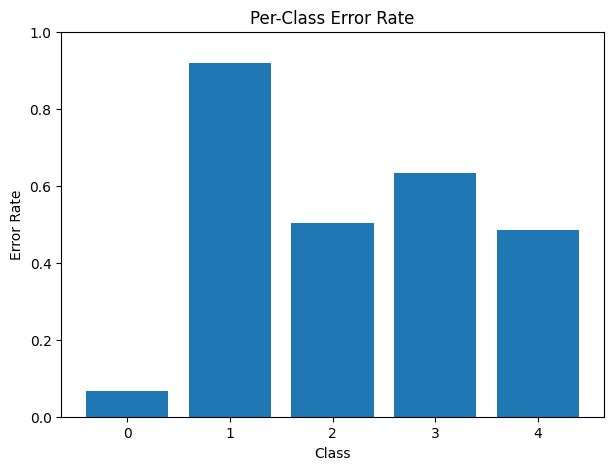

In [39]:
error_rate = 1 - (class_stats["sum"] / class_stats["count"])

plt.figure(figsize=(7,5))
plt.bar(error_rate.index.astype(str), error_rate.values)
plt.xlabel("Class")
plt.ylabel("Error Rate")
plt.ylim(0, 1)
plt.title("Per-Class Error Rate")
plt.show()

## Pre-class Recall

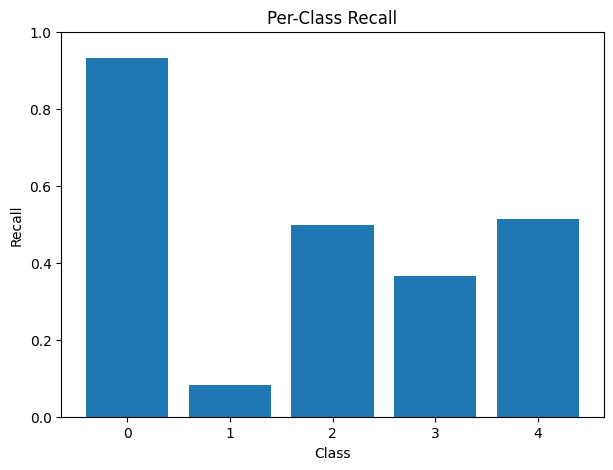

In [40]:
class_recall = class_stats["sum"] / class_stats["count"]

plt.figure(figsize=(7,5))
plt.bar(class_recall.index.astype(str), class_recall.values)
plt.xlabel("Class")
plt.ylabel("Recall")
plt.ylim(0,1)
plt.title("Per-Class Recall")
plt.show()

## Per-class Precision / Recall / F1 Bar Chart

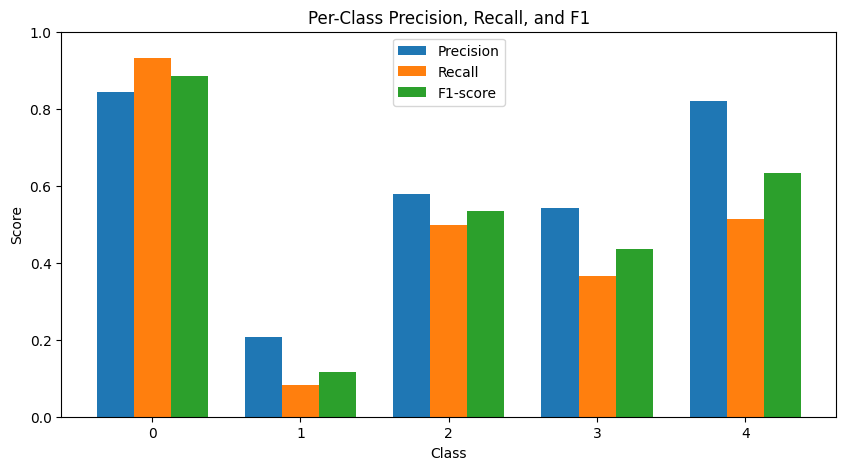

In [35]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

precision, recall, f1, _ = precision_recall_fscore_support(
    val_labels, val_preds, labels=[0,1,2,3,4], zero_division=0
)

classes = ['0', '1', '2', '3', '4']
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, and F1")
plt.legend()
plt.show()

## Class Distribution Plot

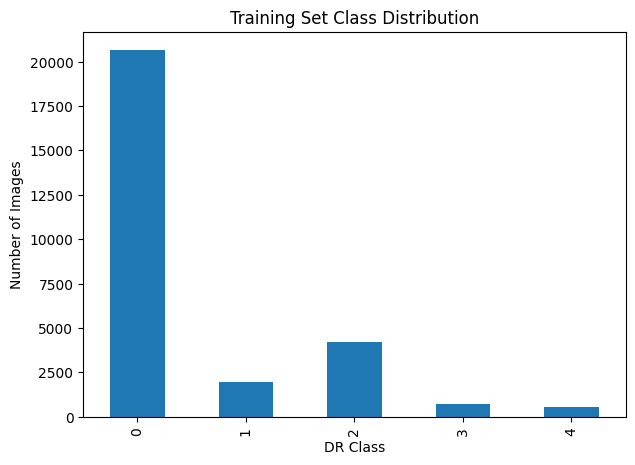

In [36]:
train_df["level"].value_counts().sort_index().plot(kind="bar", figsize=(7,5))
plt.xlabel("DR Class")
plt.ylabel("Number of Images")
plt.title("Training Set Class Distribution")
plt.show()

## Prediction distribution vs true distribution

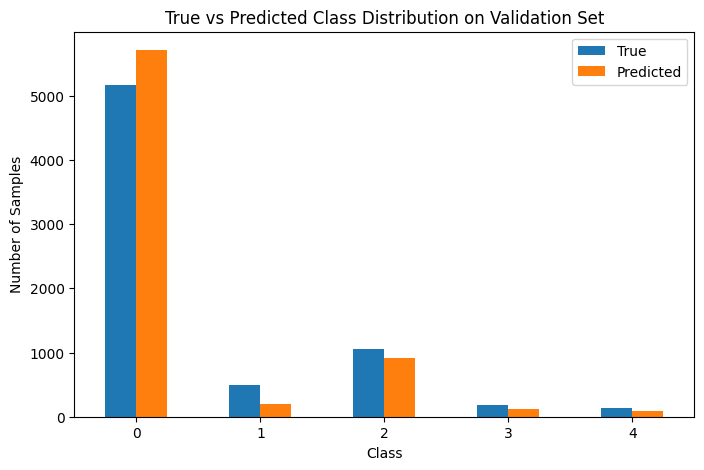

In [41]:
true_counts = pd.Series(val_labels).value_counts().sort_index()
pred_counts = pd.Series(val_preds).value_counts().sort_index()

dist_df = pd.DataFrame({
    "True": true_counts,
    "Predicted": pred_counts
}).fillna(0)

dist_df.plot(kind="bar", figsize=(8,5))
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distribution on Validation Set")
plt.xticks(rotation=0)
plt.show()

## Sample Predictions Grid

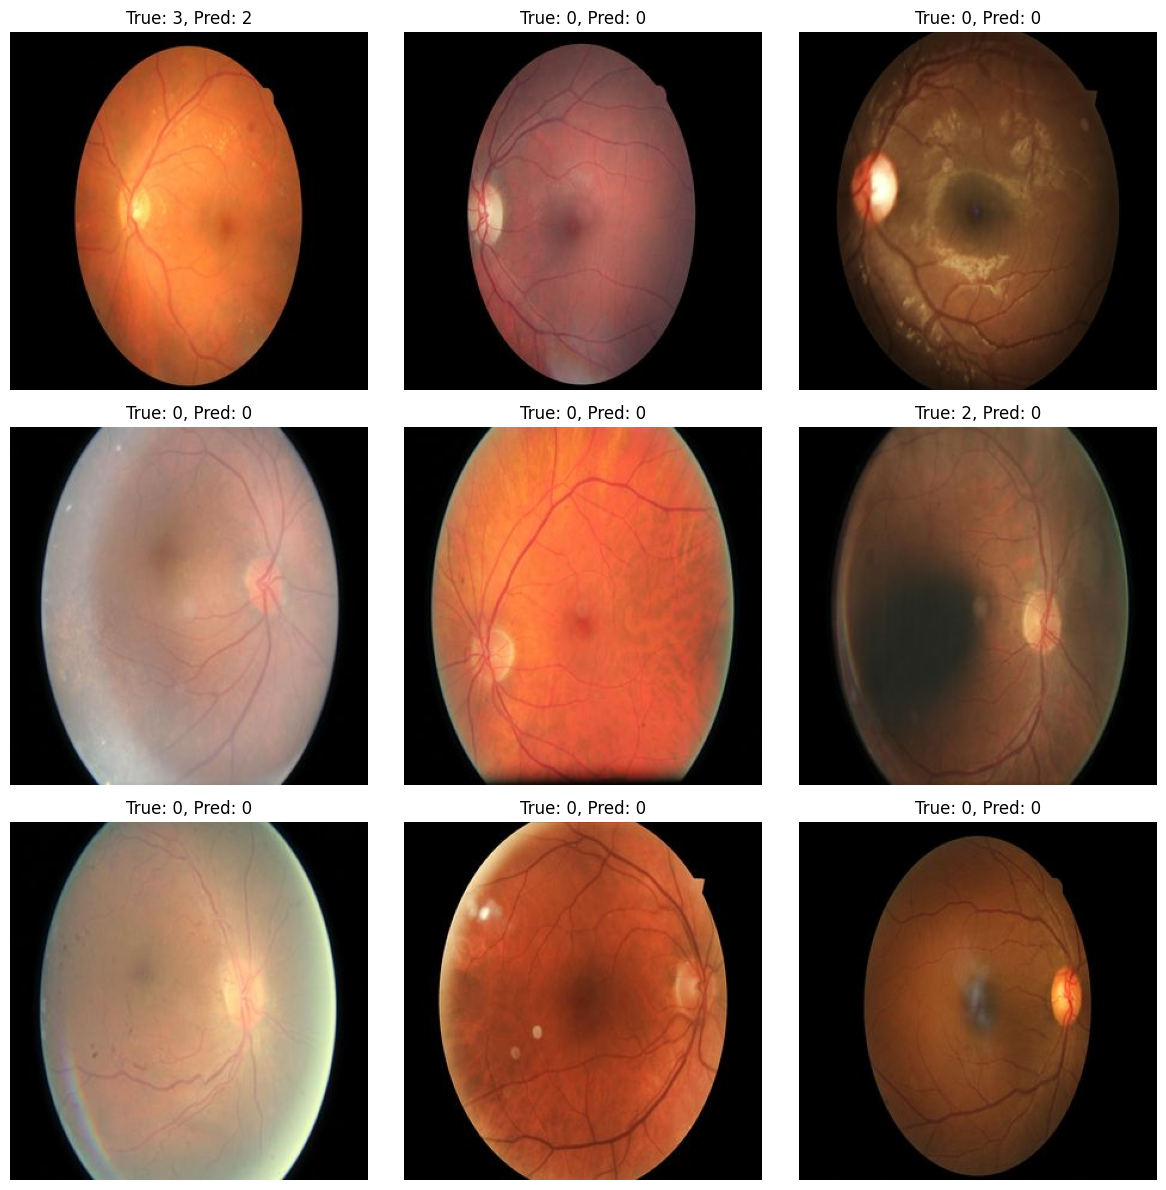

In [42]:
import random
from PIL import Image

sample_indices = random.sample(range(len(val_df)), 9)

plt.figure(figsize=(12, 12))
for i, idx in enumerate(sample_indices, 1):
    row = val_df.iloc[idx]
    img = Image.open(row["image_path"]).convert("RGB")

    # you need corresponding prediction list aligned with val_df
    true_label = row["level"]
    pred_label = val_preds[idx]

    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(f"True: {true_label}, Pred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Misclassified Predictions Grid

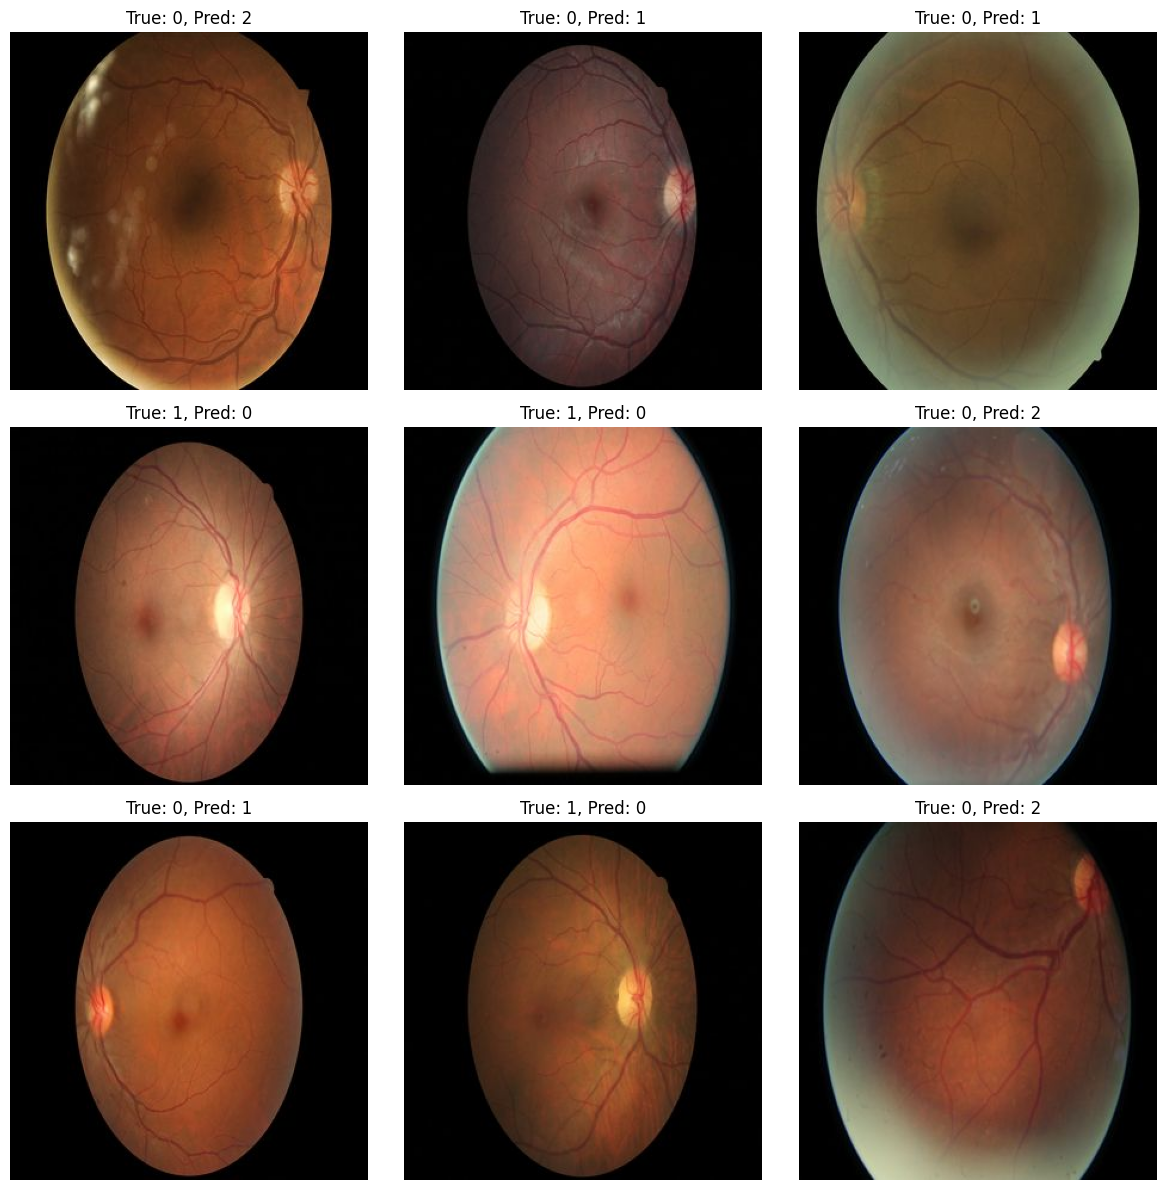

In [43]:
mis_idx = [i for i, (t, p) in enumerate(zip(val_labels, val_preds)) if t != p][:9]

plt.figure(figsize=(12, 12))
for i, idx in enumerate(mis_idx, 1):
    row = val_df.iloc[idx]
    img = Image.open(row["image_path"]).convert("RGB")

    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(f"True: {row['level']}, Pred: {val_preds[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [44]:
results_df = pd.DataFrame({
    "true": val_labels,
    "pred": val_preds
})

mistakes = results_df[results_df["true"] != results_df["pred"]]
pair_counts = mistakes.groupby(["true", "pred"]).size().sort_values(ascending=False)

print(pair_counts.head(10))

true  pred
2     0       464
1     0       398
0     2       211
      1       134
3     2        83
1     2        48
4     2        43
2     3        41
3     0        26
2     1        19
dtype: int64


## Misclassification flow heatmap

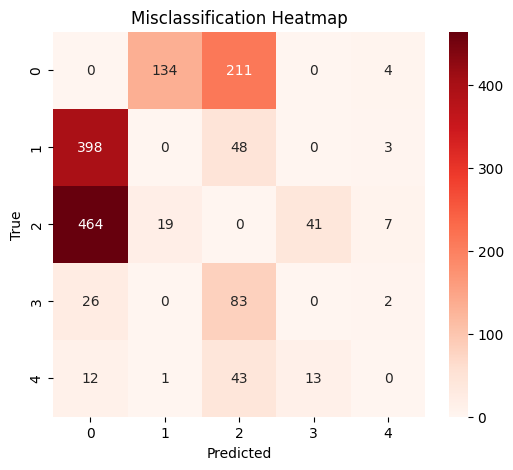

In [45]:
cm = confusion_matrix(val_labels, val_preds, labels=[0,1,2,3,4])
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_offdiag,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=[0,1,2,3,4],
    yticklabels=[0,1,2,3,4]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Misclassification Heatmap")
plt.show()

## Correct vs incorrect predictions by class

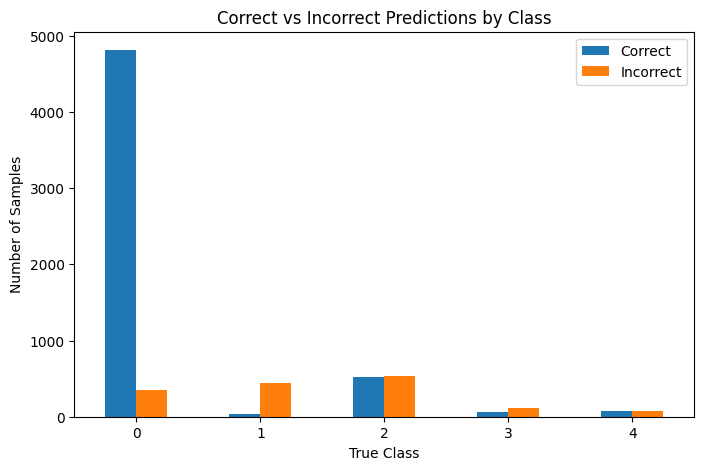

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "true": val_labels,
    "pred": val_preds
})
results_df["correct"] = results_df["true"] == results_df["pred"]

class_stats = results_df.groupby("true")["correct"].agg(["sum", "count"])
class_stats["incorrect"] = class_stats["count"] - class_stats["sum"]

class_stats[["sum", "incorrect"]].plot(
    kind="bar",
    figsize=(8,5)
)
plt.xlabel("True Class")
plt.ylabel("Number of Samples")
plt.title("Correct vs Incorrect Predictions by Class")
plt.legend(["Correct", "Incorrect"])
plt.xticks(rotation=0)
plt.show()

## Generalised Gap Plot

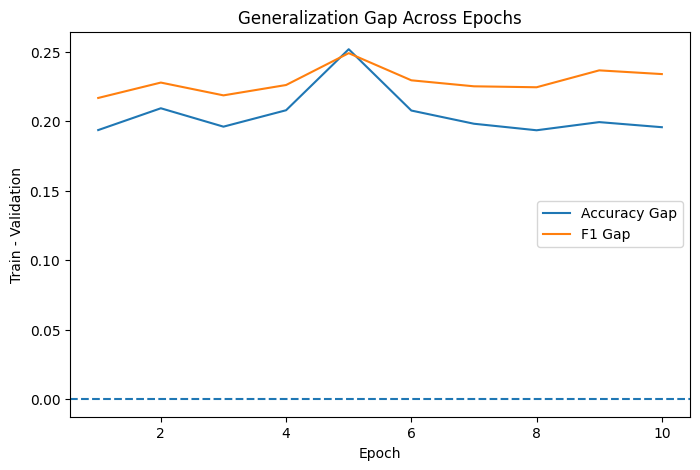

In [47]:
gap_acc = np.array(history_df["train_acc"]) - np.array(history_df["val_acc"])
gap_f1 = np.array(history_df["train_f1"]) - np.array(history_df["val_f1"])

epochs = range(1, len(gap_acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, gap_acc, label="Accuracy Gap")
plt.plot(epochs, gap_f1, label="F1 Gap")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Train - Validation")
plt.title("Generalization Gap Across Epochs")
plt.legend()
plt.show()

## Epoch-to-Epoch Improvement Graphs

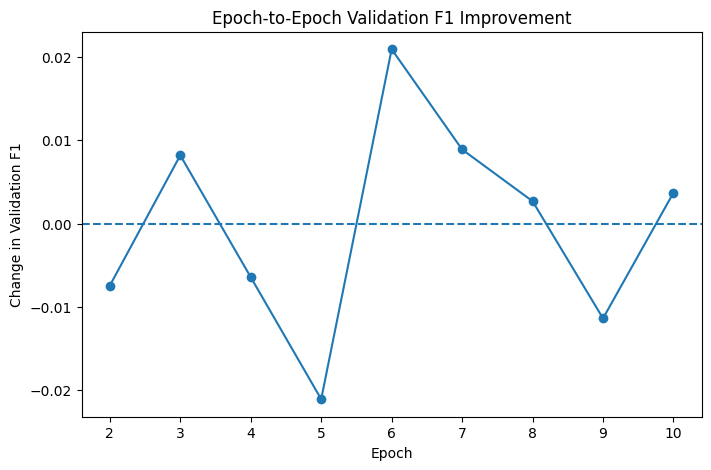

In [48]:
val_f1 = np.array(history_df["val_f1"])
delta_val_f1 = np.diff(val_f1)

plt.figure(figsize=(8,5))
plt.plot(range(2, len(val_f1)+1), delta_val_f1, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Change in Validation F1")
plt.title("Epoch-to-Epoch Validation F1 Improvement")
plt.show()

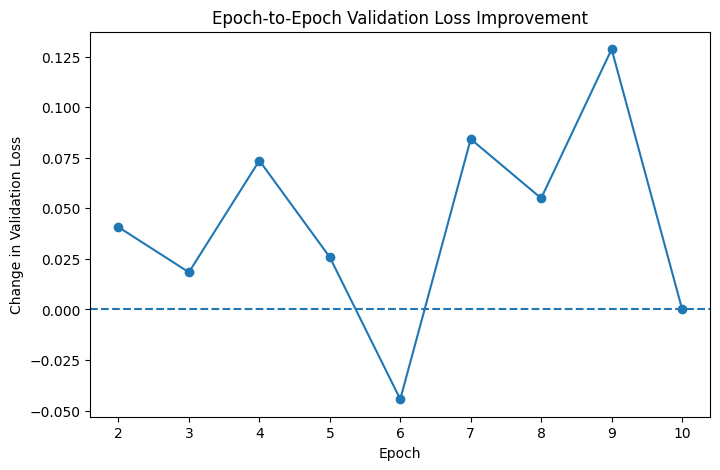

In [49]:
val_loss = np.array(history_df["val_loss"])
delta_val_loss = np.diff(val_loss)

plt.figure(figsize=(8,5))
plt.plot(range(2, len(val_f1)+1), delta_val_loss, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Change in Validation Loss")
plt.title("Epoch-to-Epoch Validation Loss Improvement")
plt.show()

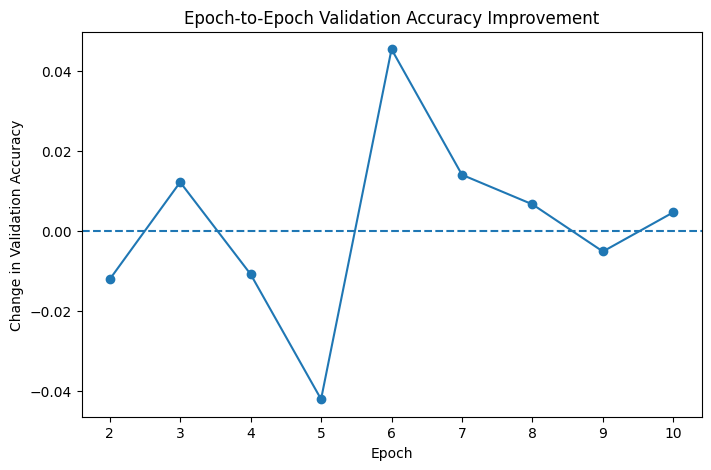

In [50]:
val_acc = np.array(history_df["val_acc"])
delta_val_acc = np.diff(val_acc)

plt.figure(figsize=(8,5))
plt.plot(range(2, len(val_f1)+1), delta_val_acc, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Change in Validation Accuracy")
plt.title("Epoch-to-Epoch Validation Accuracy Improvement")
plt.show()

In [51]:
img, label = train_dataset[0]
print(type(img), img.shape, label)

<class 'torch.Tensor'> torch.Size([3, 224, 224]) 1


In [52]:
batch = next(iter(train_loader))
images, labels = batch
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])
